# Determinare se il cliente si sottoscriverà un deposito a termine

**Programmazione di Applicazioni Data Intensive**  
Laurea in Ingegneria e Scienze Informatiche  

Lorenzo Ferri

## Descrizione del problema e analisi esplorativa

L'obiettivo del progetto è costruire un modello in grado di predire se un cliente di una banca portoghese sottoscriverà un deposito a termine (variabile target `y`: yes/no), sulla base di informazioni demografiche, finanziarie e relative alle precedenti campagne di marketing telefonico.

Il dataset utilizzato è il **[Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing)** del repository UCI, nella sua versione completa (`bank-full.csv`), contenente 45.211 istanze e 17 feature.

### Librerie

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

### Caricamento e prima esplorazione dei dati

Carichiamo il dataset e ne visualizziamo le prime righe per capire com'è strutturato.

In [3]:
bmds = pd.read_csv('bank-full.csv', sep=';')
bmds

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


Verifichiamo le dimensioni, i tipi di dato e la presenza di valori nulli. Non ci sono valori nulli espliciti: i dati mancanti sono mascherati dalla stringa `"unknown"` in alcune variabili categoriche, che identificheremo e gestiremo durante l'analisi esplorativa.

In [4]:
bmds.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 25.7 MB


### Significato delle singole feature

Prima di procedere con l'analisi, riportiamo il significato di ogni variabile così come documentato dalla [fonte](https://archive.ics.uci.edu/dataset/222/bank+marketing) del dataset.

Dati:

* **`age`** (numeric)
* **`job`** : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student"
                                        "blue-collar","self-employed","retired","technician","services") 
* **`marital`** : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
* **`education`** (categorical: "unknown","secondary","primary","tertiary")
* **`default`**: has credit in default? (binary: "yes","no")
* **`balance`**: average yearly balance, in euros (numeric) 
* **`housing`**: has housing loan? (binary: "yes","no")
* **`loan`**: has personal loan? (binary: "yes","no")

Related with the last contact of the current campaign:
* **`contact`**: contact communication type (categorical: "unknown","telephone","cellular") 
* **`day`**: last contact day of the month (numeric)
* **`month`**: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
* **`duration`**: last contact duration, in seconds (numeric)

Other attributes:
* **`campaign`**: number of contacts performed during this campaign and for this client (numeric, includes last contact)
* **`pdays`**: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
* **`previous`**: number of contacts performed before this campaign and for this client (numeric)
* **`poutcome`**: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

Output variable (desired target):
* **`y`**: has the client subscribed a term deposit? (binary: "yes","no")

### Esplorazione delle singole feature

Analizziamo la distribuzione di ogni variabile attraverso statistiche descrittive e grafici. L'obiettivo è individuare anomalie, valori mancanti mascherati, distribuzioni molto sbilanciate o variabili poco informative, così da decidere come trattarle prima dell'addestramento dei modelli.

#### Age
Si nota che la maggior parte dei clienti è concentrata tra i 30 e i 50 anni

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64


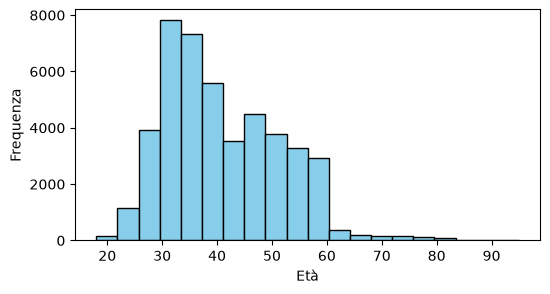

In [5]:
print(bmds['age'].describe())
plt.figure(figsize=(6,3))
plt.hist(bmds['age'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Età')
plt.ylabel('Frequenza')
plt.show()

#### Job
Presenta una minima percentuale di dati mancanti mascherati come "unknown", che verranno rimossi per pulire il dataset.

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


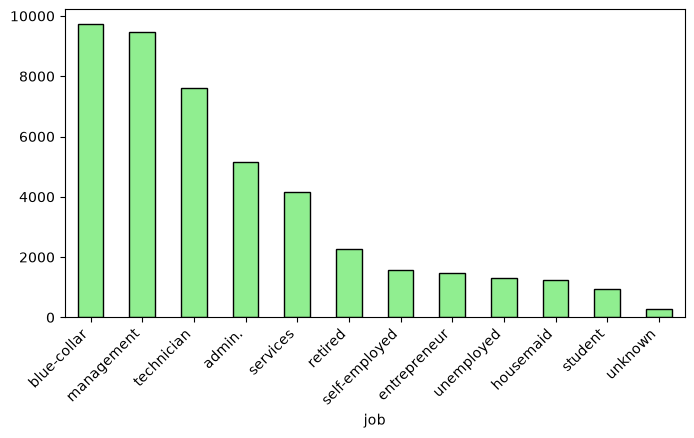

In [6]:
print(bmds['job'].value_counts())
plt.figure(figsize=(8,4))
bmds['job'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.show()

bmds = bmds[bmds['job'] != 'unknown']

#### Marital
La categoria married è dominante nel dataset

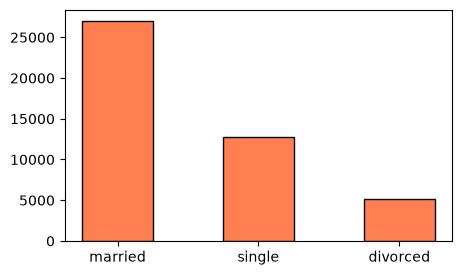

In [7]:
counts = bmds['marital'].value_counts()
plt.figure(figsize=(5,3))
plt.bar(counts.index, counts.values, color='coral', edgecolor='black', width=0.5)
plt.show()

#### Educational
Contiene una minima percentuale di valori "unknown", le righe corrispondenti verranno rimosse per garantire l'affidabilità dell'informazione.

education
secondary    23131
tertiary     13262
primary       6800
unknown       1730
Name: count, dtype: int64


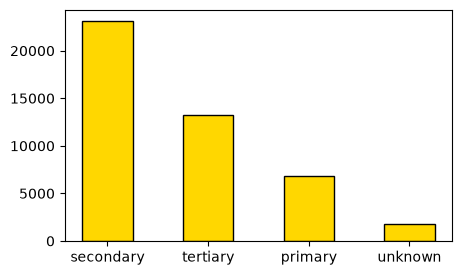

In [8]:
print(bmds['education'].value_counts())
counts = bmds['education'].value_counts()
plt.figure(figsize=(5,3))
plt.bar(counts.index, counts.values, color='gold', edgecolor='black', width=0.5)
plt.show()

bmds = bmds[bmds['education'] != 'unknown']

#### Default
Quasi tutti i valori sono *no* (>98%): la variabile è praticamente non informativa. Viene rimossa dal dataset.

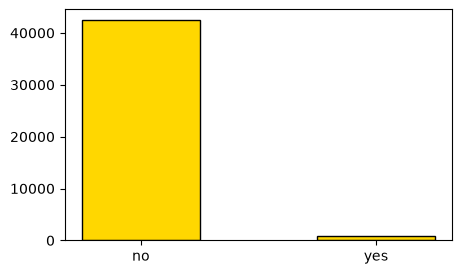

In [9]:
counts = bmds['default'].value_counts()
plt.figure(figsize=(5,3))
plt.bar(counts.index, counts.values, color='gold', edgecolor='black', width=0.5)
plt.show()

bmds.drop(columns=['default'], inplace=True)

#### Balance
Si nota che quasi il 60% della clientela si concentra nella fascia di '1-1500'

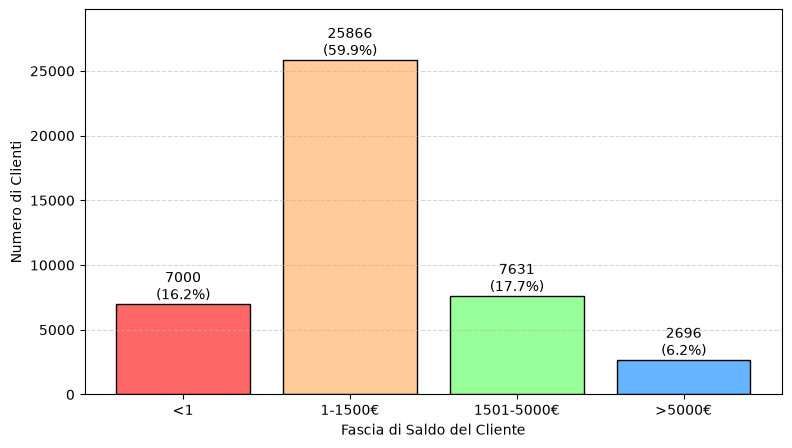

In [10]:
bmds['balance_category'] = pd.cut(bmds['balance'],
    bins=[-float('inf'), 0, 1500, 5000, float('inf')],
    labels=['<1', '1-1500€', '1501-5000€', '>5000€']
)

#Contiamo quanti clienti finiscono in ogni categoria
ordine_categorie = ['<1', '1-1500€', '1501-5000€', '>5000€']
conteggi = bmds['balance_category'].value_counts().reindex(ordine_categorie)


plt.figure(figsize=(9, 5))
colori = ['#ff6666', '#ffcc99', '#99ff99', '#66b3ff']

plt.bar(conteggi.index, conteggi.values, color=colori, edgecolor='black')

for i, valore in enumerate(conteggi.values):
    plt.text(i, valore, f"{valore}\n({valore/len(bmds)*100:.1f}%)", ha='center', va='bottom')

plt.xlabel('Fascia di Saldo del Cliente')
plt.ylabel('Numero di Clienti')
plt.ylim(0, max(conteggi.values) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Rimuoviamo la colonna temporanea
bmds = bmds.drop(columns=['balance_category'])

#### Housing
Le due categorie sono quasi bilanciate

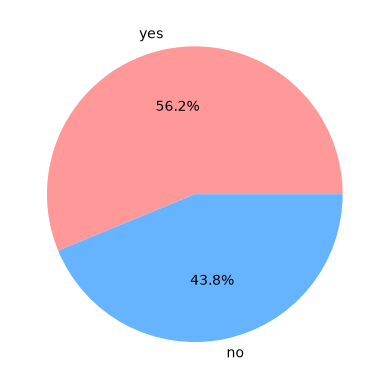

In [11]:
bmds['housing'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.ylabel('')
plt.show()

#### Loan
La maggior parte dei clienti non ha prestiti personali attivi.

In [12]:
print(bmds['loan'].value_counts())

loan
no     36086
yes     7107
Name: count, dtype: int64


#### Contact
Una grossa quantità dei valori presenta "unknown", ma li teniamo e li consideriamo come categoria

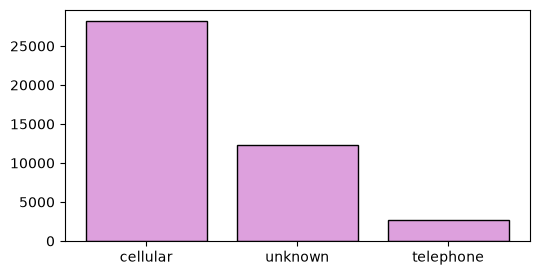

In [13]:
counts = bmds['contact'].value_counts()
plt.figure(figsize=(6,3))
plt.bar(counts.index, counts.values, color='plum', edgecolor='black')
plt.show()

#### Day
La distribuzione è uniforme senza alcun pattern rispetto al target. Non porta informazione utile e viene rimossa.

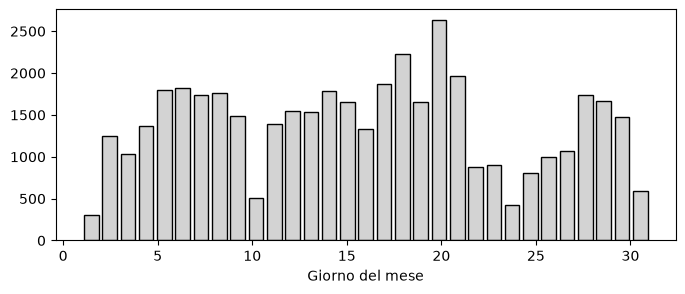

In [14]:
plt.figure(figsize=(8,3))
plt.hist(bmds['day'], bins=31, rwidth=0.8, color='lightgray', edgecolor='black')
plt.xlabel('Giorno del mese')
plt.show()

bmds.drop(columns=['day'], inplace=True)

#### Month
C'è una fortissima concentrazione di chiamate nel mese di maggio, mentre i mesi autunnali/invernali hanno pochissimi record.

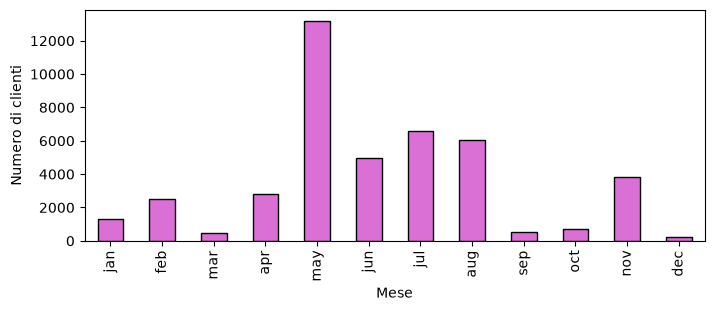

In [15]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month = bmds['month'].astype(pd.CategoricalDtype(categories=month_order, ordered=True)).sort_values()

plt.figure(figsize=(8,3))
month.value_counts().sort_index().plot(kind='bar', color='orchid', edgecolor='black')
plt.xlabel('Mese')
plt.ylabel('Numero di clienti')
plt.show()


#### Duration
Come riportato anche dal sito del dataset:
la durata è nota solo a fine chiamata, quando l'esito è già determinato.
Se la durata è 0 allora anche y è 0. 

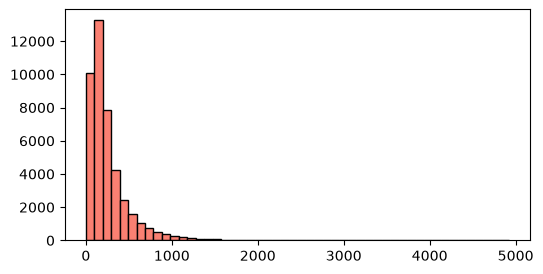

In [16]:
plt.figure(figsize=(6,3))
plt.hist(bmds['duration'], bins=50, color='salmon', edgecolor='black')
plt.show()

#### Campaign
Presenta una distribuzione asimmetrica. La maggior parte riceve da 1 a 3 chiamate, ma ci sono casi estremi di clienti con oltre 50 chiamate ricevute

In [17]:
print(bmds['campaign'].describe())

count    43193.000000
mean         2.758178
std          3.063987
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         58.000000
Name: campaign, dtype: float64


#### Pdays
Saturata di valori -1 (cliente mai contattato prima).

In [18]:
bmds['pdays'].value_counts()

pdays
-1      35281
 182      151
 92       138
 183      120
 91       115
        ...  
 541        1
 543        1
 871        1
 550        1
 530        1
Name: count, Length: 557, dtype: int64

#### Previous 
Per i clienti nuovi, il valore è logicamente 0.
Caso simile a Pdays

In [19]:
bmds['previous'].value_counts().head(10)

previous
0    35281
1     2651
2     2004
3     1096
4      693
5      443
6      268
7      195
8      127
9       88
Name: count, dtype: int64

#### Poutcome
Quasi tutti i valori sono "unknown", coerentemente con il fatto che la maggior parte dei clienti non ha precedenti campagne.

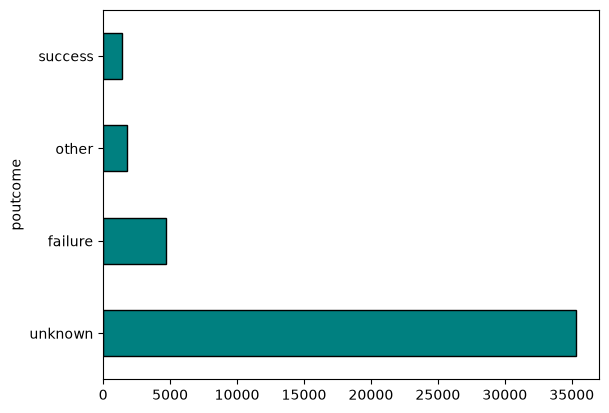

In [20]:
bmds['poutcome'].value_counts().plot(kind='barh', color='teal', edgecolor='black')
plt.show()

#### Variabile target: y
Il dataset è altamente sbilanciato, con circa l'90% di risposte "no" e solo il 10% di "yes"

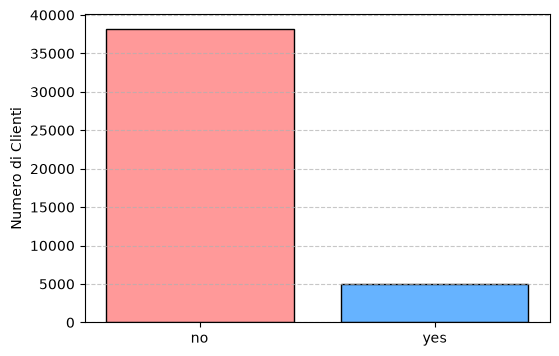

In [21]:
target_counts = bmds['y'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index, target_counts.values, color=['#ff9999', '#66b3ff'], edgecolor='black')

plt.ylabel('Numero di Clienti')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Esplorazione delle relazioni tra feature

Dopo aver analizzato le distribuzioni singole, esploriamo come alcune variabili si relazionano con il target `y`. L'obiettivo è capire quali feature hanno un potere predittivo più alto e come si differenzia il comportamento dei clienti che accettano rispetto a quelli che rifiutano.

#### Age e y
I clienti più giovani (<30) e quelli anziani (>60) mostrano un tasso di accettazione leggermente superiore rispetto alla fascia 30-55 anni, che è anche la più rappresentata.

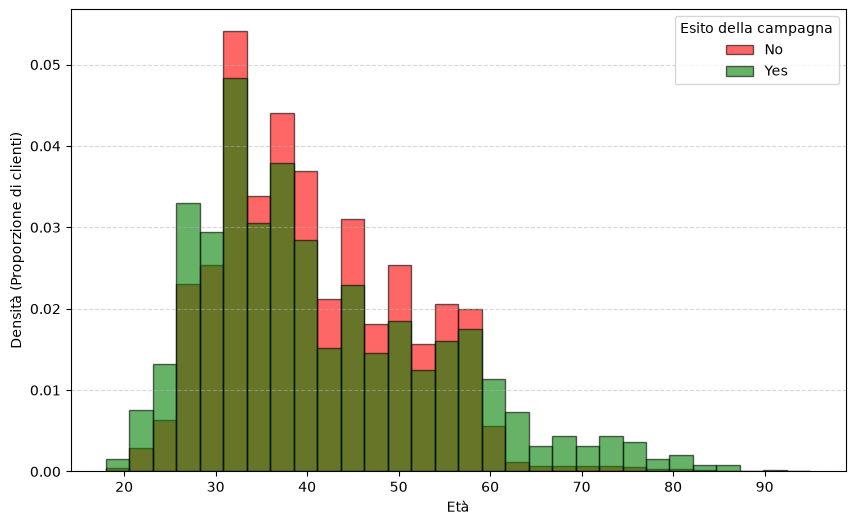

In [22]:
age_no = bmds[bmds['y'] == 'no']['age']
age_yes = bmds[bmds['y'] == 'yes']['age']

plt.figure(figsize=(10, 6))

plt.hist(age_no, bins=30, alpha=0.6, color='red', label='No', edgecolor='black', density=True)
plt.hist(age_yes, bins=30, alpha=0.6, color='green', label='Yes', edgecolor='black', density=True)

plt.xlabel('Età')
plt.ylabel('Densità (Proporzione di clienti)')
plt.legend(title='Esito della campagna')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Job e y
I pensionati e gli studenti hanno il tasso di sottoscrizione più elevato; gli operai e i servizi il più basso.

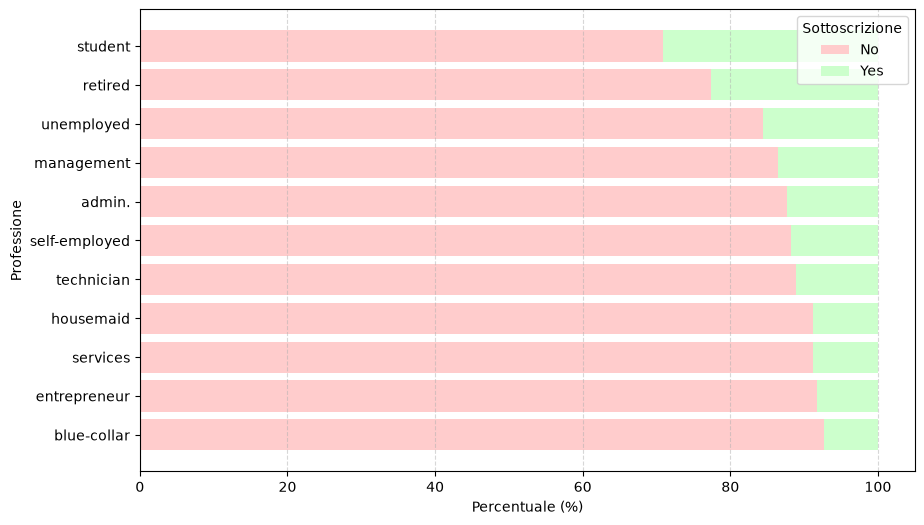

In [23]:
job_target = pd.crosstab(bmds['job'], bmds['y'], normalize='index') * 100

job_target = job_target.sort_values(by='yes', ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(job_target.index, job_target['no'], label='No', color='#ffcccc')
plt.barh(job_target.index, job_target['yes'], left=job_target['no'], label='Yes', color='#ccffcc')

plt.xlabel('Percentuale (%)')
plt.ylabel('Professione')
plt.legend(title='Sottoscrizione')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

#### Duration e y
Come previsto e menzionato dalla fonte: i clienti che hanno accettato mostrano una durata media della chiamata nettamente superiore.

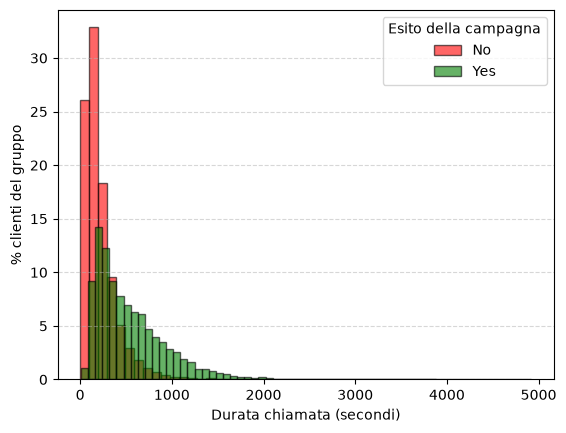

In [24]:
groups = [bmds[bmds['y'] == val]['duration'] for val in ['no', 'yes']]

total_no  = len(groups[0])
total_yes = len(groups[1])

plt.hist(groups[0], bins=50, alpha=0.6, color='red', label='No',
         edgecolor='black', weights=np.ones(total_no) / total_no * 100)
plt.hist(groups[1], bins=50, alpha=0.6, color='green', label='Yes',
         edgecolor='black', weights=np.ones(total_yes) / total_yes * 100)

plt.xlabel('Durata chiamata (secondi)')
plt.ylabel('% clienti del gruppo')
plt.legend(title='Esito della campagna')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Poutcome e y
Chi aveva già accettato in una campagna precedente tende a farlo di nuovo con frequenza molto più alta rispetto alle altre categorie.

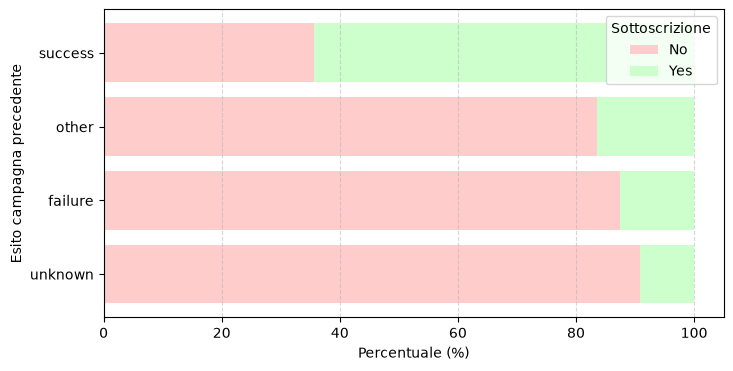

In [25]:
poutcome_target = pd.crosstab(bmds['poutcome'], bmds['y'], normalize='index') * 100
poutcome_target = poutcome_target.sort_values(by='yes', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(poutcome_target.index, poutcome_target['no'], label='No', color='#ffcccc')
plt.barh(poutcome_target.index, poutcome_target['yes'], left=poutcome_target['no'], label='Yes', color='#ccffcc')
plt.xlabel('Percentuale (%)')
plt.ylabel('Esito campagna precedente')
plt.legend(title='Sottoscrizione')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

#### Month e y
Marzo, settembre, ottobre e dicembre hanno il tasso di conversione più alto. Maggio, pur avendo il maggior volume di chiamate, ha un tasso di successo nella media.

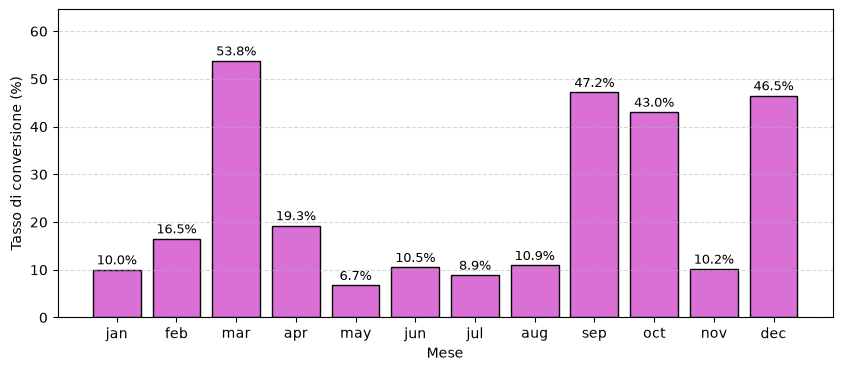

In [26]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_rate = bmds.groupby('month')['y'].apply(lambda x: (x == 'yes').mean() * 100)
month_rate = month_rate.reindex(month_order).dropna()

plt.figure(figsize=(10, 4))
plt.bar(month_rate.index, month_rate.values, color='orchid', edgecolor='black')
for i, val in enumerate(month_rate.values):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.xlabel('Mese')
plt.ylabel('Tasso di conversione (%)')
plt.ylim(0, max(month_rate.values) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Feature engineering

`season` cattura il segnale stagionale che `month` frammentava in 12 categorie: ciò che conta per il modello non è il singolo mese, ma il periodo dell'anno. I grafici hanno mostrato che autunno e dicembre hanno tassi di conversione nettamente superiori all'estate, un pattern che la variabile stagione rende immediatamente leggibile. `contacted_before` sintetizza `pdays` e `previous` in un'unica informazione binaria: il fatto che un cliente sia già stato contattato in passato è il dato rilevante, non il numero esatto di giorni o di chiamate precedenti, che risultavano quasi sempre nulli.

##### Season

In [27]:
season_map = {
    'dec': 'winter', 'jan': 'winter', 'feb': 'winter',
    'mar': 'spring', 'apr': 'spring', 'may': 'spring',
    'jun': 'summer', 'jul': 'summer', 'aug': 'summer',
    'sep': 'autumn', 'oct': 'autumn', 'nov': 'autumn'
}
bmds['season'] = bmds['month'].map(season_map)

bmds.drop(columns=['month'], inplace=True)

bmds['season'].value_counts()

season
summer    17618
spring    16460
autumn     5064
winter     4051
Name: count, dtype: int64

##### Contacted_before

In [28]:
bmds['contacted_before'] = (bmds['pdays'] != -1).astype(int)
bmds.drop(columns=['pdays', 'previous'], inplace=True)
bmds['contacted_before'].value_counts()

contacted_before
0    35281
1     7912
Name: count, dtype: int64

#### Eliminazione della feature Duration

Dovuto da ciò che si è notato nelle sezioni precedenti e come spiegato anche nella fonte del dataset. La feature verrà rimossa per avere un modello più realistico.

In [29]:
bmds.drop(columns=['duration'], inplace=True)

#### Heatmap di correlazione per le feature numeriche
Le feature numeriche sono in generale poco correlate tra loro.

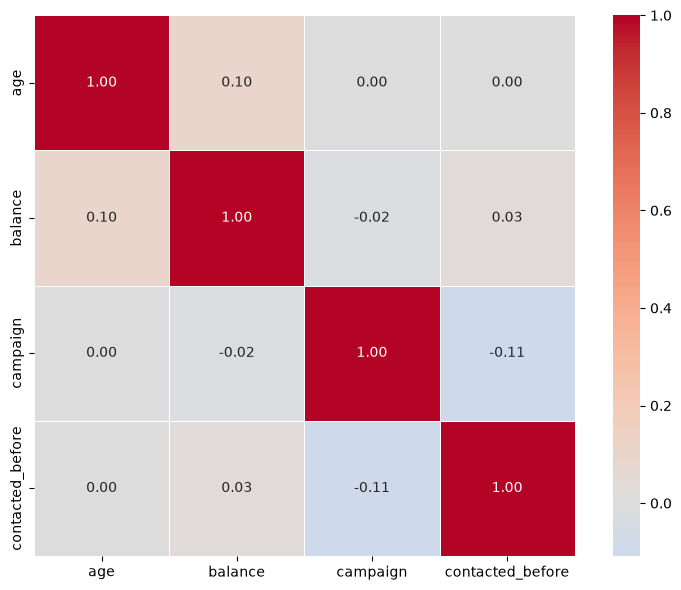

In [31]:
num_features = ['age', 'balance', 'campaign', 'contacted_before']
corr_matrix = bmds[num_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.tight_layout()
plt.show()

## Preprocessing per l'addestramento

Prima di addestrare i modelli è necessario trasformare il dataset in una forma che gli algoritmi di machine learning sappiano gestire. Il dataset presenta variabili binarie in formato testuale, variabili categoriche con più categorie e un target fortemente sbilanciato: tutti elementi che devono essere trattati prima dell'addestramento.

### Librerie

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

### Codifica delle variabili binarie

Le variabili `housing` e `loan` sono binarie (yes/no) ma in formato testuale: le convertiamo in 1/0 per renderle direttamente utilizzabili dai modelli. Facciamo lo stesso con il target `y`.

In [33]:
bmds['housing'] = bmds['housing'].map({'yes': 1, 'no': 0})
bmds['loan']    = bmds['loan'].map({'yes': 1, 'no': 0})
bmds['y']       = bmds['y'].map({'yes': 1, 'no': 0})

bmds.head()

,age,job,marital,education,balance,housing,loan,contact,campaign,poutcome,y,season,contacted_before
0,58,management,married,tertiary,2143,1,0,unknown,1,unknown,0,spring,0
1,44,technician,single,secondary,29,1,0,unknown,1,unknown,0,spring,0
2,33,entrepreneur,married,secondary,2,1,1,unknown,1,unknown,0,spring,0
5,35,management,married,tertiary,231,1,0,unknown,1,unknown,0,spring,0
6,28,management,single,tertiary,447,1,1,unknown,1,unknown,0,spring,0


### Suddivisione train/test

Dividiamo il dataset in training set (2/3) e test set (1/3). Il parametro `stratify=y` garantisce che la proporzione delle classi (~88% no, ~12% yes) venga mantenuta in entrambe le partizioni, evitando che lo split casuale crei uno sbilanciamento aggiuntivo.

In [34]:
y = bmds['y']
X = bmds.drop(columns=['y'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

Training set : (28795, 12)
Test set     : (14398, 12)


### One-Hot Encoding delle variabili categoriche

Le colonne `job`, `marital`, `education`, `contact`, `poutcome` e `season` vengono trasformate: per ogni categoria viene creata una colonna binaria (0/1).

L'encoder viene addestrato **solo sul training set** e poi applicato al test set.

In [35]:
cat_cols = ['job', 'marital', 'education', 'contact', 'poutcome', 'season']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[cat_cols])

ohe_train = pd.DataFrame(
    encoder.transform(X_train[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)
ohe_test = pd.DataFrame(
    encoder.transform(X_test[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

X_train = X_train.drop(columns=cat_cols).join(ohe_train)
X_test  = X_test.drop(columns=cat_cols).join(ohe_test)

print(f"Feature totali dopo OHE: {X_train.shape[1]}")
X_train.head()

Feature totali dopo OHE: 34


,age,balance,housing,loan,campaign,contacted_before,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,season_autumn,season_spring,season_summer,season_winter
33692,35,1750,1,0,3,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4466,39,4904,1,0,1,0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
18532,38,1911,1,0,4,0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
17504,31,3,1,0,4,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
31511,45,1683,1,0,1,0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


### Gestione dello sbilanciamento delle classi — Oversampling con SMOTE

Con il 90% delle istanze etichettate come *no*, un modello che ignora completamente la classe *yes* raggiungerebbe già il 90% di accuracy. SMOTE genera esempi sintetici della classe minoritaria interpolando tra campioni reali esistenti: il risultato è un training set bilanciato che forza i modelli ad apprendere le caratteristiche dei clienti *yes* invece di ignorarli. Viene applicato solo sul training set: il test set resta con la distribuzione originale per misurare le performance sul problema reale.

In [36]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribuzione prima del SMOTE:")
print(y_train.value_counts())
print("\nDistribuzione dopo il SMOTE:")
print(y_train_res.value_counts())

Distribuzione prima del SMOTE:
y
0    25448
1     3347
Name: count, dtype: int64

Distribuzione dopo il SMOTE:
y
1    25448
0    25448
Name: count, dtype: int64


## Modellizzazione

Vengono testati quattro modelli di classificazione: Perceptron, Logistic Regression, Decision Tree e Random Forest.

Per ogni modello viene eseguita una **Grid Search** combinata con **K-Fold Cross Validation** (k=5): la ricerca prova sistematicamente tutte le combinazioni di iperparametri definite nella griglia, valutando ciascuna su 5 fold diversi del training set. Questo rende la stima delle performance più robusta rispetto a un singolo split. I migliori iperparametri trovati vengono poi usati per la valutazione finale sul test set.

### Librerie

In [37]:
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler 

In [38]:
k_fold = KFold(n_splits=5, shuffle=True, random_state=42)
models = {}

def grid_search_and_train(pipeline, grid, X_train, y_train):
    gs = GridSearchCV(pipeline, grid, scoring='f1_weighted', cv=k_fold, n_jobs=-1)
    gs.fit(X_train, y_train)
    print(f'  Migliori parametri : {gs.best_params_}')
    print(f'  Miglior F1 (CV)    : {gs.best_score_:.4f}')
    return gs.best_estimator_, gs.best_score_

feature_names = list(X_train.columns)

### Perceptron

Il Perceptron è il modello più semplice: un classificatore lineare che aggiorna i pesi solo in caso di predizione errata. 

Gli iperparametri esplorati sono:
- `penalty`: tipo di regolarizzazione applicata ai pesi (`l1`, `l2` o nessuna)
- `alpha`: intensità della regolarizzazione
- `fit_intercept`: se includere o meno l'intercetta alla funzione

In [39]:
per_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('per', Perceptron(random_state=42, max_iter=1000))
])

per_grid = {
    'scaler': [None, StandardScaler()],
    'per__penalty': ['l1', 'l2', None, 'elasticnet'],
    'per__alpha': np.logspace(-4, 0, 5),
    'per__fit_intercept': [True, False]
}

per_best, per_score = grid_search_and_train(per_pipeline, per_grid, X_train_res, y_train_res)
models['Perceptron'] = {'model': per_best, 'cv_score': per_score}

  Migliori parametri : {'per__alpha': np.float64(0.001), 'per__fit_intercept': True, 'per__penalty': 'l1', 'scaler': StandardScaler()}
  Miglior F1 (CV)    : 0.7159


### Logistic Regression

Metodo per ottenere un piano di separazione non ottimale ma lineare.

 Gli iperparametri esplorati sono:
- `C`: inverso dell'intensità di regolarizzazione (valori alti riducono la regolarizzazione)
- `penalty`: tipo di penalizzazione (`l1` produce modelli sparsi, `l2` distribuisce i pesi)
- `fit_intercept`: se includere o meno l'intercetta alla funzione

In [ ]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(solver='liblinear', random_state=42))
])

lr_grid = {
    'scaler': [None, StandardScaler()],
    'lr__penalty': ['l1', 'l2'],
    'lr__C': np.logspace(-3, 2, 5),
    'lr__fit_intercept': [True, False]
}

lr_best, lr_score = grid_search_and_train(lr_pipeline, lr_grid, X_train_res, y_train_res)
models['Logistic Regression'] = {'model': lr_best, 'cv_score': lr_score}

c:\Users\loren\VisualStudioCode\DataIntensive\ProgettoEsame\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


  Migliori parametri : {'lr__C': np.float64(100.0), 'lr__fit_intercept': True, 'lr__penalty': 'l2', 'scaler': StandardScaler()}
  Miglior F1 (CV)    : 0.7945


### Decision Tree

L'albero decisionale deduce regole di classificazione direttamente dai dati, suddividendo ricorsivamente lo spazio delle feature. E' un metodo concettualmente semplice e non richiede grande preparazione dei dati ma in certe situazioni potrebbe non avere grandi performance in termini di capacità di apprendimento e adattamento a nuovi dati.

 Vengono regolate:
- `max_depth`: profondità massima dell'albero
- `min_samples_split`: numero minimo di campioni necessari per dividere un nodo
- `min_samples_leaf`: numero minimo di campioni richiesti in una foglia

In [41]:
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tree', DecisionTreeClassifier(random_state=42))
])

dt_grid = {
    'scaler': [None, StandardScaler()],
    'tree__max_depth': [None] + [i for i in range(2, 30, 2)],
    'tree__min_samples_split': range(2, 12, 2),
    'tree__min_samples_leaf': range(1, 11, 2)
}

dt_best, dt_score = grid_search_and_train(dt_pipeline, dt_grid, X_train_res, y_train_res)
models['Decision Tree'] = {'model': dt_best, 'cv_score': dt_score}

  Migliori parametri : {'scaler': StandardScaler(), 'tree__max_depth': 12, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 8}
  Miglior F1 (CV)    : 0.9193


### Random Forest

La Random Forest è un metodo di ensemble che addestra un insieme di alberi decisionali indipendenti su sottoinsiemi casuali dei dati e delle feature, aggregando poi le loro predizioni per voto di maggioranza. Questo meccanismo riduce significativamente l'overfitting tipico del singolo albero. Gli iperparametri esplorati sono:
- `n_estimators`: numero di alberi nella foresta
- `max_depth`: profondità massima di ciascun albero
- `min_samples_split`: numero minimo di campioni per effettuare uno split

In [ ]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('forest', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_grid = {
    'scaler': [None, StandardScaler()],
    'forest__n_estimators'    : range(5, 10),
    'forest__max_depth'       : [None] + [i for i in range(2, 30, 2)],
    'forest__min_samples_split': range(2, 11)
}

rf_best, rf_score = grid_search_and_train(rf_pipeline, rf_grid, X_train_res, y_train_res)
models['Random Forest'] = {'model': rf_best, 'cv_score': rf_score}

  Migliori parametri : {'forest__max_depth': 21, 'forest__min_samples_split': 7, 'forest__n_estimators': 9, 'scaler': StandardScaler()}
  Miglior F1 (CV)    : 0.9349


### Riepilogo F1-score

Di seguito il riepilogo dell'F1-score medio ottenuto in cross validation per ciascun modello. Questi valori sono stime della performance sul training set e non sul test set, che verrà usato nella fase di valutazione finale.

In [43]:
cv_summary = pd.DataFrame([
    {'Modello': name, 'F1 Score': round(info['cv_score'], 4)}
    for name, info in models.items()
]).set_index('Modello')
cv_summary

,F1 Score
Modello,
Perceptron,0.7159
Logistic Regression,0.7945
Decision Tree,0.9193
Random Forest,0.9349


## Valutazione dei modelli

Con un dataset sbilanciato 90/10 l'accuracy è una metrica ingannevole. Il recall misura quanti clienti *yes* vengono effettivamente identificati: un recall basso significa che molti clienti potenzialmente interessati vengono ignorati, con conseguente perdita di opportunità di business. La precision misura quanti dei clienti classificati come *yes* lo sono davvero: una precision bassa porta a contattare molti clienti non interessati. L'F1-score bilancia entrambe le metriche e rappresenta il compromesso ottimale tra le due.

In [44]:
results = []

for name, info in models.items():
    y_pred = info['model'].predict(X_test)
    results.append({
        'Modello'  : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, average='weighted'),
        'F1-score' : f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results).set_index('Modello')
results_df

,Accuracy,Precision,Recall,F1-score
Modello,,,,
Perceptron,0.541464,0.809063,0.541464,0.622620
Logistic Regression,0.781706,0.855294,0.781706,0.809867
Decision Tree,0.881581,0.859089,0.881581,0.865883
Random Forest,0.890054,0.866229,0.890054,0.867991


### Matrici di confusione

La matrice di confusione mostra nel dettaglio come ogni modello distribuisce le proprie predizioni tra le due classi.

In [45]:
from sklearn.metrics import confusion_matrix


for idx, (name, info) in enumerate(models.items()):
    y_pred = info['model'].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print(name)
    print(pd.DataFrame(cm, index=info['model'].classes_, columns=info['model'].classes_))
    print("\n")


Perceptron
      0     1
0  6906  5818
1   784   890


Logistic Regression
       0     1
0  10343  2381
1    762   912


Decision Tree
       0    1
0  12252  472
1   1233  441


Random Forest
       0    1
0  12444  280
1   1303  371




### Intervalli di confidenza

Un intervallo che include lo zero indica che i due modelli non sono statisticamente distinguibili al 95% di confidenza: la differenza osservata nelle performance potrebbe essere dovuta alla variabilità del campione di test e non a una reale superiorità di un modello sull'altro. Intervalli interamente positivi o negativi confermano invece che un modello è genuinamente superiore. Questo è utile per evitare di scegliere un modello più complesso quando uno più semplice offre performance statisticamente equivalenti.

In [46]:
from scipy import stats

def difference_between_two_models(error1, error2, confidence):
    z_half_alfa = stats.norm.ppf(confidence)
    variance = (((1 - error1) * error1) / len(y_test)) + (((1 - error2) * error2) / len(y_test))
    d_minus = abs(error1 - error2) - z_half_alfa * (pow(variance, 0.5))
    d_plus  = abs(error1 - error2) + z_half_alfa * (pow(variance, 0.5))
    print("Valore minimo: {}\nValore massimo: {}\n".format(d_minus, d_plus))

per_error    = 1 - results_df.loc['Perceptron', 'Accuracy']
lr_error     = 1 - results_df.loc['Logistic Regression', 'Accuracy']
tree_error   = 1 - results_df.loc['Decision Tree', 'Accuracy']
forest_error = 1 - results_df.loc['Random Forest', 'Accuracy']

print("Perceptron vs Logistic Regression:")
difference_between_two_models(per_error, lr_error, 0.95)

print("Logistic Regression vs Decision Tree:")
difference_between_two_models(lr_error, tree_error, 0.95)

print("Decision Tree vs Random Forest:")
difference_between_two_models(tree_error, forest_error, 0.95)


Perceptron vs Logistic Regression:
Valore minimo: 0.2313692605725738
Valore massimo: 0.24911413989971398

Logistic Regression vs Decision Tree:
Valore minimo: 0.09268591631560368
Valore massimo: 0.10706404895735096

Decision Tree vs Random Forest:
Valore minimo: 0.0023085198364067253
Valore massimo: 0.014638278330005255



Il confronto tra Perceptron e Logistic Regression produce un intervallo interamente positivo e lontano dallo zero: la Logistic Regression è molto superiore al Perceptron.

Il confronto tra Logistic Regression e Decision Tree è ancora significativo ma con un distacco minore. 

Il confronto tra Decision Tree e Random Forest l'intervallo prodotto esclude lo zero ma appena, indicando che la Random Forest è 
leggermente migliore ma la differenza è molto contenuta, i due modelli sono quasi equivalenti su questo dataset.

## Analisi dei modelli

### Coefficienti della Logistic Regression

Nella regressione logistica ogni feature ha un coefficiente che indica la direzione e l'intensità del suo contributo alla predizione: valori positivi aumentano la probabilità di predire *yes*, valori negativi la riducono. Visualizziamo le 10 feature con coefficiente più alto e le 10 più basso.

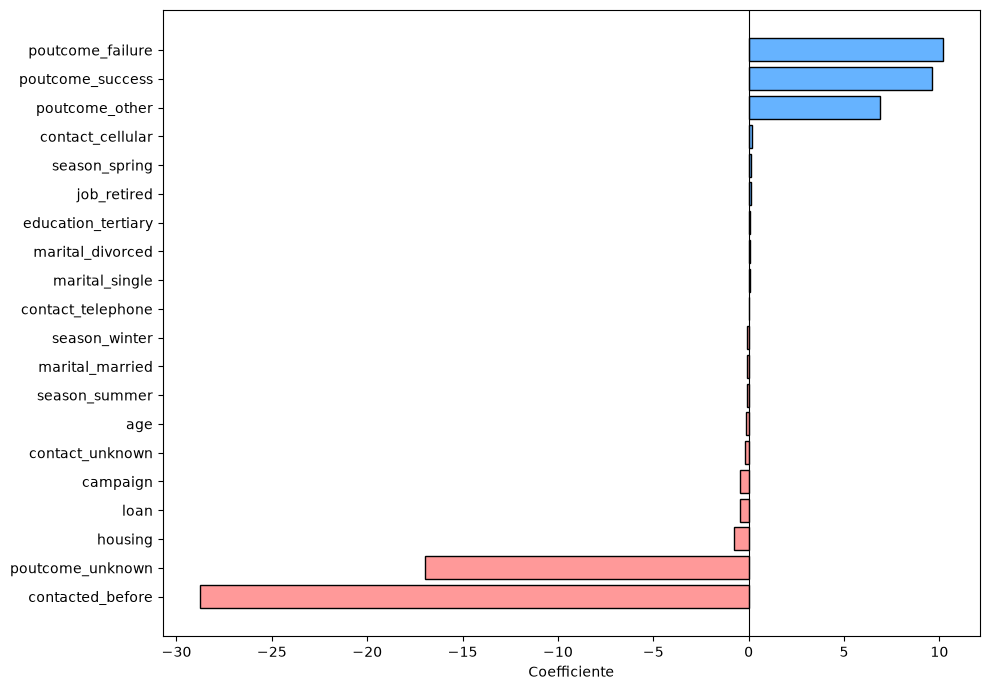

In [47]:
lr_step = models['Logistic Regression']['model'].named_steps['lr']

coef_df = pd.DataFrame({
    'Feature'     : feature_names,
    'Coefficiente': lr_step.coef_[0]
}).sort_values('Coefficiente', ascending=False)

top_features = pd.concat([coef_df.head(10), coef_df.tail(10)])

plt.figure(figsize=(10, 7))
colors = ['#66b3ff' if c > 0 else '#ff9999' for c in top_features['Coefficiente']]
plt.barh(top_features['Feature'], top_features['Coefficiente'],
         color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficiente')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Il coefficiente più alto appartiene a poutcome_failure: i clienti che avevano già rifiutato in passato mostrano comunque una propensione maggiore rispetto a chi non ha mai partecipato a una 
campagna.

### Feature importance del Random Forest

L'importanza di una feature indica quanto frequentemente viene usata nei nodi alti degli alberi, dove le divisioni sono più discriminative. Una feature con importanza alta significa che la foresta la considera la variabile più efficace per separare i clienti. 

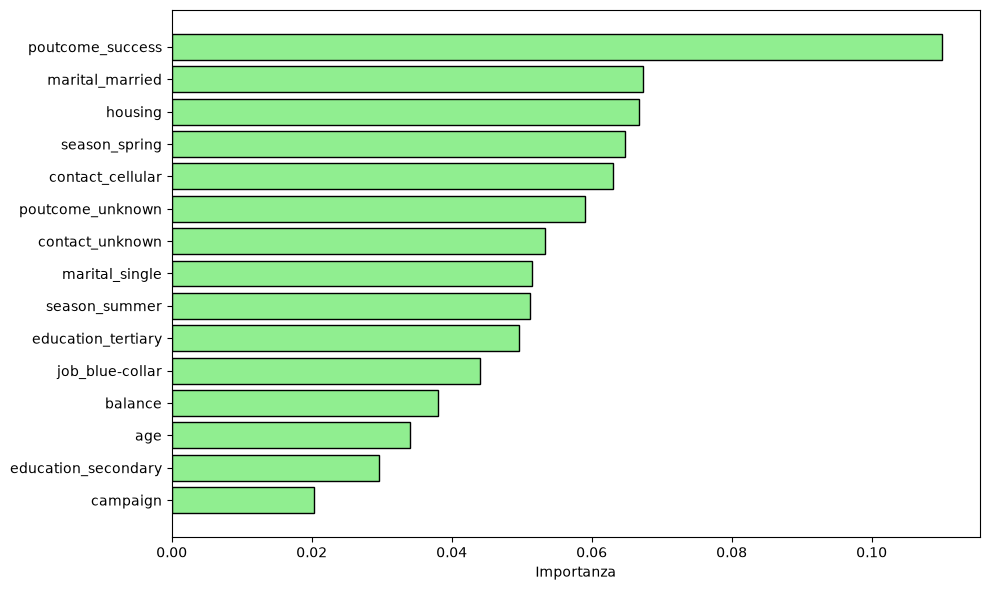

In [51]:
rf_step = models['Random Forest']['model'].named_steps['forest']

importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': rf_step.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='lightgreen', edgecolor='black')
plt.xlabel('Importanza')
plt.tight_layout()
plt.show()

poutcome_success domina con un'importanza di quasi il doppio rispetto alla seconda feature. Il resto dell'importanza è distribuito in modo molto più uniforme.

### Primi livelli del Decision Tree

Visualizziamo i primi 3 livelli dell'albero decisionale ottimizzato. I nodi radice rivelano quali feature il modello considera più discriminanti per la prima suddivisione, e permettono di confrontare queste scelte con le osservazioni fatte durante la fase esplorativa.

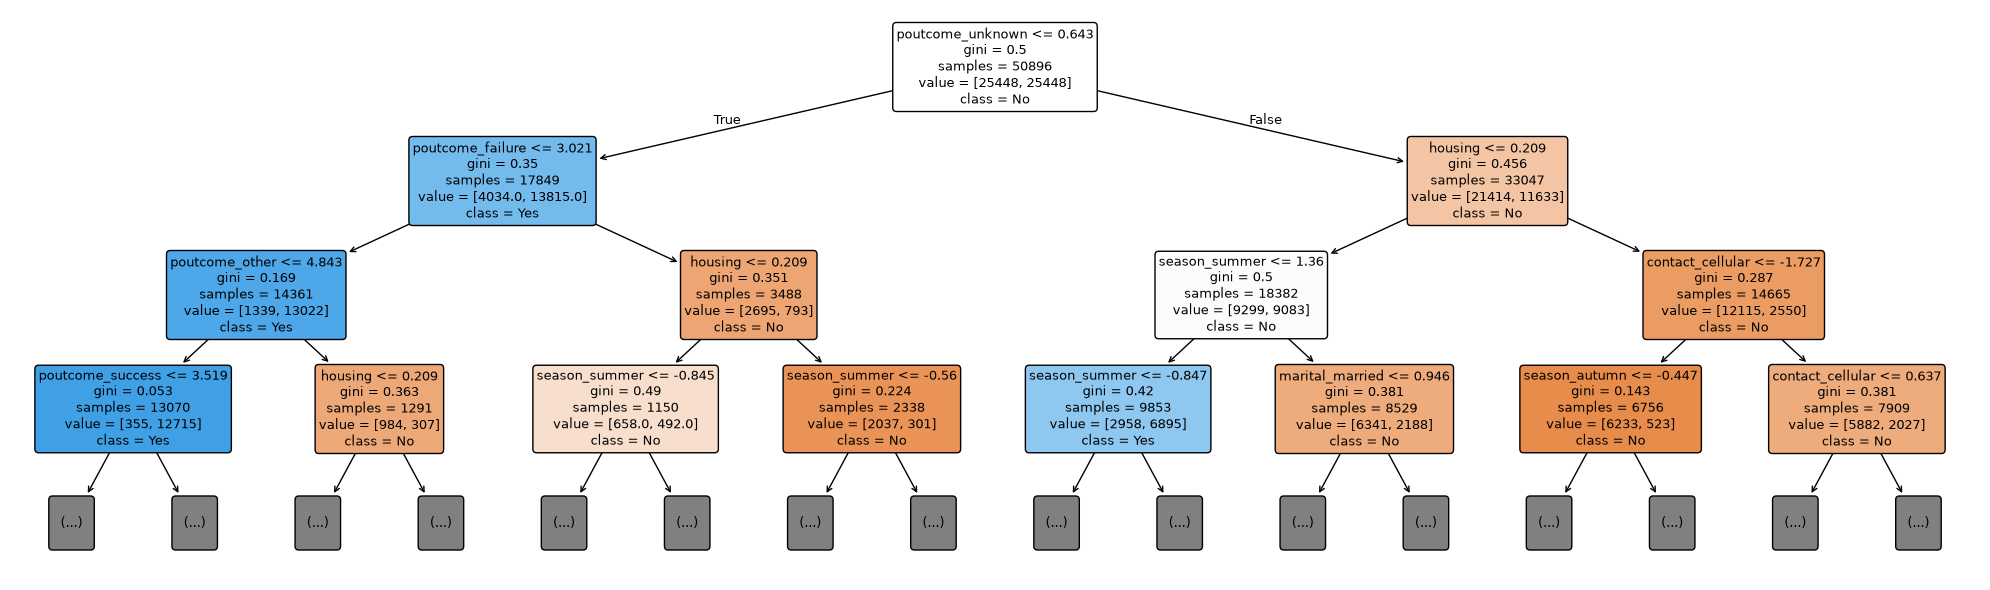

In [ ]:
from sklearn.tree import plot_tree

dt_step = models['Decision Tree']['model'].named_steps['tree']

plt.figure(figsize=(20, 6))
plot_tree(
    dt_step,
    max_depth=3,
    feature_names=feature_names,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.tight_layout()
plt.show()

Il nodo radice divide su poutcome_unknown: i clienti alla prima campagna (ramo sinistro) vengono subito separati da chi ha già una storia con la banca. Nel ramo sinistro il modello usa poutcome_failure come secondo criterio, classificando già come Yes i clienti che avevano rifiutato in precedenza. Nel ramo destro invece emergono housing e season come variabili discriminanti, suggerendo che per i clienti con storia non nota il profilo demografico e il momento della campagna diventano i fattori più rilevanti.